# TEMPO v1.1 Spike Train Visualization

Generate a dataset of 3 words with 5 noisy spike trains each, then visualize using raster plots.

In [4]:
import subprocess
import tempfile
import os

# Write a small wordlist
wordlist_path = os.path.join(tempfile.gettempdir(), "demo_wordlist.txt")
dataset_path = os.path.join(tempfile.gettempdir(), "demo_dataset.h5")

with open(wordlist_path, "w") as f:
    f.write("ACE BAD CAB\n")

# Generate dataset: 3 words x 5 spike trains, all noise enabled
result = subprocess.run(
    ["python", "-m", "tempo.dataset.generate_dataset",
     wordlist_path, dataset_path,
     "--wpm", "20",
     "--duration", "10",
     "--multiplier", "5",
     "--seed", "42"],
    capture_output=True, text=True
)
print(result.stderr)

usage: generate_dataset.py [-h] [--wpm WPM] [--multiplier MULTIPLIER]
                           [--weighting] [--dash-ratio] [--jitter]
                           [--all-noise] [--seed SEED]
                           wordlist output
generate_dataset.py: error: unrecognized arguments: --duration 10



In [ ]:
from tempo.dataset.tempo_dataset import TEMPODataset

ds = TEMPODataset(dataset_path)
print(f"Samples: {len(ds)}")
print(f"Classes: {ds.num_classes}")
print(f"Mapping: {ds.word_to_id}")
print(f"Spike tensor shape: {ds.spikes.shape}")

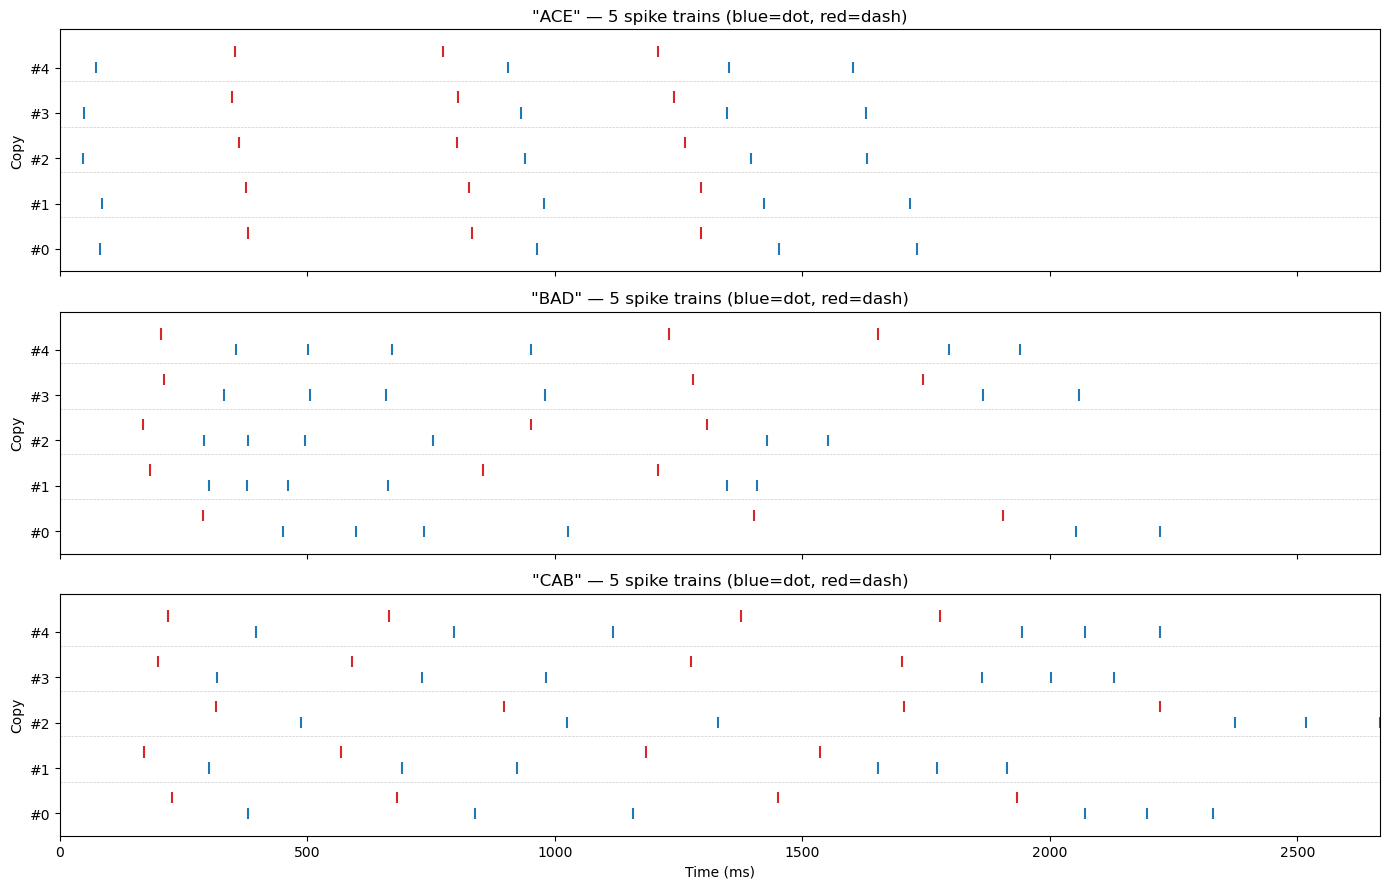

In [6]:
import matplotlib.pyplot as plt
import torch

fig, axes = plt.subplots(ds.num_classes, 1, figsize=(14, 3 * ds.num_classes), sharex=True)

colors = {0: "#1f77b4", 1: "#d62728"}  # blue for dots, red for dashes
channel_labels = ["Dot", "Dash"]

for class_id in range(ds.num_classes):
    ax = axes[class_id]
    word = ds.id_to_word[class_id]

    # Get all sample indices for this word
    sample_indices = (ds.labels == class_id).nonzero(as_tuple=True)[0]

    for row, idx in enumerate(sample_indices):
        spike_tensor = ds.spikes[idx]  # (Time, 2)
        for ch in range(2):
            times = spike_tensor[:, ch].nonzero(as_tuple=True)[0].numpy()
            y_pos = row + (ch * 0.35)  # offset channels slightly
            ax.eventplot(
                times, lineoffsets=y_pos, linelengths=0.25,
                colors=colors[ch], linewidths=1.5
            )

        # Add horizontal separator between spike trains
        if row < len(sample_indices) - 1:
            ax.axhline(y=row + 0.7, color="#cccccc", linewidth=0.5, linestyle="--")

    ax.set_ylabel("Copy")
    ax.set_yticks(range(len(sample_indices)))
    ax.set_yticklabels([f"#{i}" for i in range(len(sample_indices))])
    ax.set_title(f'"{word}" — 5 spike trains (blue=dot, red=dash)')
    ax.set_xlim(0, ds.spikes.shape[1])

axes[-1].set_xlabel("Time (ms)")
fig.tight_layout()
plt.show()